In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pickle
import glob
import sys

# Make local code importable (expects Code/compute_session_alignment.py)
sys.path.append('./Code/')
import compute_session_alignment

from collections import Counter
from joblib import Parallel, delayed

# ---------------------------------------------------------------------
# Decoders: mean‐template variants
# ---------------------------------------------------------------------
def letter_decoding_mean(x_train, x_test, y_train, y_test, shuffle=False):
    """
    Mean‐template decoding that compares per‐class mean TEST activity to
    per‐class mean TRAIN templates using cosine similarity, but counts
    accuracy at the **class‐mean** level (i.e., 1 correct per class).

    Args
    ----
    x_train, x_test : array (trials × time × features) BEFORE windowing.
    y_train, y_test : array (trials,) with discrete class labels.
    shuffle         : bool, if True shuffles y labels for a null/control.

    Returns
    -------
    score_matrix : (n_win × n_win) array of counts (not normalized).
                   Entry (ti, tj) = number of classes correctly predicted
                   when training a template at window ti and testing on
                   class means at window tj.
    n_classes    : int, number of unique classes present in training labels.
    """
    
    n_win = len(window_ranges)
    score_matrix = np.zeros((n_win, n_win))

    # Copy/alias labels (already integers/strings)
    y_train_encoded = y_train
    y_test_encoded  = y_test
    class_labels    = [0,1] #np.unique(y_train_encoded)

    # Average activity in sliding windows and baseline‐correct by FIX bins
    #print((x_train.shape,x_test.shape),flush=True)
    xTTrain_all = [np.mean(x_train[:, start:end, :], axis=1) #- np.mean(x_train[:, 0:4, :], axis=1)
                   for (start, end) in window_ranges]
    xTTest_all  = [np.mean(x_test[:, start:end, :], axis=1)  #- np.mean(x_test[:, 0:4, :], axis=1)
                   for (start, end) in window_ranges]

    if shuffle:
        # Shuffle labels independently for train/test for a conservative null
        np.random.shuffle(y_train_encoded)
        np.random.shuffle(y_test_encoded)

    all_templates = []  # keep templates from each TRAIN window (for inspection)
    for ti, xTTrain in enumerate(xTTrain_all):
        for tj, xTTest in enumerate(xTTest_all):
            if(ti==tj):
                # --- TRAIN: build one mean template per class (in window ti)
                templates = []
                for c in class_labels:
                    class_indices = np.where(y_train_encoded == c)[0]
                    template = np.mean(xTTrain[class_indices], axis=0)
                    templates.append(template)
                templates = np.array(templates)  # (n_classes × n_features)

                if tj == 0:
                    all_templates.append(templates)

                # --- TEST: compare per‐class MEAN test activity to templates
                correct = 0
                for c_idx, c in enumerate(class_labels):
                    test_indices = np.where(y_test_encoded == c)[0]
                    if len(test_indices) == 0:
                        continue

                    # mean vector for THIS class/window
                    test_vec = np.mean(xTTest[test_indices], axis=0)

                    # Cosine similarity to each template -> scalars
                    corrs = [
                        float(np.dot(test_vec, tpl) / (np.linalg.norm(test_vec) * np.linalg.norm(tpl) + 1e-8))
                        for tpl in templates
                    ]

                    # tie-break
                    if len(corrs) == 2 and np.isclose(corrs[0], corrs[1]):
                        predicted_class_idx = np.random.choice([0, 1])
                    else:
                        predicted_class_idx = int(np.argmax(corrs))

                    predicted_class = class_labels[predicted_class_idx]
                    if predicted_class == c:
                        correct += 1
                        

            score_matrix[ti, tj] = correct  # raw count (not %)
            
    return score_matrix, 2, #len(class_labels)

In [10]:
units = np.load('../Data/units.npy',allow_pickle=True)
units[6][0]

array(['uAHL1_0', 'uAHL1_4', 'uAHL1_5', 'uAHL2_0', 'uAHL3_0', 'uAHL4_1',
       'uAHL5_0', 'uAHL7_1', 'uAHL7_4', 'uAL8_17', 'uAL8_19', 'uECL3_14',
       'uPHL2_3', 'uPHR1_1', 'uPHR3_5', 'uPHR5_1', 'uPHR6_2', 'uPHR6_4',
       'uPHR6_5', 'uPHR6_6', 'uPHR6_7', 'uPHR6_8', 'uPHR6_9', 'uPHR7_16',
       'uPHR7_2', 'uPHR7_3', 'uPHR7_8'], dtype=object)

In [11]:
completeBinned = np.load('../Data/binned.npy', allow_pickle=True)
completeBinned[1].shape

(99, 16, 16)

In [12]:
letters        = np.load('../Data/letters.npy')
uniqueLetters = np.array([p for p in np.unique(letters) if p not in ['Q', 'W', 'X']])
uniqueLetters

array(['B', 'C', 'D', 'F', 'G', 'H', 'K', 'L', 'N', 'P', 'R', 'S', 'T',
       'V', 'Z'], dtype='<U1')

In [13]:
subj_ses = np.load('../Data/subjs_sep.npy',allow_pickle=True)
len(subj_ses)

35

In [15]:
from copy import deepcopy
NPC_TO_ALIGN = 5
# ---------------------------------------------------------------------
# Shared/static variables (loaded once)
# ---------------------------------------------------------------------
# NOTE: The following variables are referenced later. Make sure they are
# defined prior to calling functions that use them.

# Load all data (paths assume ../Data/ exists)
probes         = np.load('../Data/probes.npy')
subj           = np.load('../Data/subjs.npy')
subj_ses       = np.load('../Data/subjs_sep.npy', allow_pickle=True)
inout          = np.load('../Data/in.npy')
letters        = np.load('../Data/letters.npy')
letters_ses    = np.load('../Data/letters_sep.npy', allow_pickle=True)
probes_ses     = np.load('../Data/probes_sep.npy', allow_pickle=True)
units          = np.load('../Data/units.npy',allow_pickle=True)

# Subject/session metadata
sses          = [s[0] for s in subj_ses]
uniqueSub     = np.unique(sses)

# Letters (exclude rarely used or unwanted letters)
uniqueLetters = np.array([p for p in np.unique(letters) if p not in ['Q', 'W', 'X']])
n_labels      = len(uniqueLetters)

# Sliding windows: 4 bins wide, sliding by 1 bin (29 positions)
window_ranges = [(i, i + 1) for i in range(16)]

# ---------------------------------------------------------------------
# One permutation "trial": align, project, decode (for one letter)
# ---------------------------------------------------------------------
t1 = 2
t2 = 16
def single_trial(ktrial, letter_index):
    retry = 0 
    ok = False
    while not ok:
        maskSub = [subj_ses[i][0]!=outSub for i in range(len(subj_ses))]
        completeBinned = np.load('../Data/binned.npy', allow_pickle=True)
        completeBinned = completeBinned[maskSub]
        #Counter(subj)

        data = []
        train_test_labels = []

        Y      = [np.array([[1 if u in letterString else 0 for u in uniqueLetters] for letterString in ls], dtype=int)
                 for ls in letters_ses[maskSub]]
        
        Yprobe = [np.array([[1 if u in letterString else 0 for u in uniqueLetters] for letterString in ls], dtype=int)
                 for ls in probes_ses[maskSub]]
         
        #maskSET_TEST  = [np.sum(yi,axis=1)>0 for yi in Y]
        #maskSET_TRAIN = [np.sum(yi,axis=1)>0 for yi in Y]
        
        maskSET_TEST  = [np.sum(yi*yp,axis=1)==0 for (yi,yp) in zip(Y,Yprobe)]
        maskSET_TRAIN = [np.sum(yi*yp,axis=1)==0 for (yi,yp) in zip(Y,Yprobe)]
        #print(maskSET_TEST,flush=True)
        
        units =  np.load('../Data/units.npy', allow_pickle=True)
        units = units[maskSub]

        all_maskU = []
        newcompleteBinned = []
        newY = []
        newMaskSET_TEST  = []
        newMaskSET_TRAIN = []
        for i in range(len(completeBinned)):
            
            maskU = [list(np.where(['R' in ui for ui in units[i][0]])[0])+
            #list(np.where(['AHL' in ui for ui in units[i][0]])[0])+
            #list(np.where(['PHR' in ui for ui in units[i][0]])[0])+
            list(np.where(['L' in ui for ui in units[i][0]])[0])][0]
            
            
            bst = completeBinned[i]
            #print(bst.shape,flush=True)
            #print(maskU,flush=True)
            
            bst = bst[:,maskU]
            bst = np.transpose(bst, (1, 2, 0))
            if len(bst) >= NPC_TO_ALIGN:
                newcompleteBinned.append(completeBinned[i])
                newY.append(Y[i])
                newMaskSET_TEST.append(maskSET_TEST[i])
                newMaskSET_TRAIN.append(maskSET_TRAIN[i])
                tt_label  = np.random.uniform(0, 1, len(bst[0][0])) > 0.5
                #tt_label = np.zeros(len(bst[0][0]))
                #tt_label[np.random.choice(np.arange(len(tt_label)),
                #                          size=1,
                #                          replace=False)] = 1

                condition = Y[i][:, letter_index]

                mask    = np.logical_and(tt_label == 0,condition>-1)
                timeB   = np.arange(len(bst[0])) * 0.250
                session = {
                    'response' : bst[:,:,mask],#bst[:, :, tt_label == 0],
                    'condition': condition[mask],#condition[tt_label == 0],
                    'time'     : timeB
                }
                data.append(session)
                all_maskU.append(maskU)
                train_test_labels.append(tt_label)


        pars = {'alignment': {'nPCs_align': NPC_TO_ALIGN, 'cond_contrast': (1, 0)}, 'align_proj': {'condition_vars': []}}

        D_align, D_cond_avg_proj_align, align_stats = compute_session_alignment.compute_session_alignment_CONTRAST_2BIAS(data, [], pars,t1,t2)

        Z_align = deepcopy(D_align)
        #print(len(all_maskU),len(train_test_labels),len(newcompleteBinned),len(D_align),newcompleteBinned[0].shape,flush=True)
        X = np.concatenate([Z_align[i]['response'] for i in range(len(Z_align))], axis=2)
        #X = X[accepted_components]
        projected_X = [
            np.transpose(newcompleteBinned[sesID][:,all_maskU[sesID]], (0, 2, 1)) @ D_align[sesID]['U'] + D_align[sesID]['bias'] #[:, accepted_components]
            for sesID in range(len(newcompleteBinned))
        ]

        #print(len(projected_X),flush=True)
        X_train = [projected_X[i][np.logical_and(train_test_labels[i] == 0, newMaskSET_TRAIN[i])] for i in range(len(train_test_labels))]
        X_test  = [projected_X[i][np.logical_and(train_test_labels[i] == 1, newMaskSET_TEST[i])] for i in range(len(train_test_labels))]
        Y_train = [newY[i][np.logical_and(train_test_labels[i] == 0, newMaskSET_TRAIN[i]), letter_index] for i in range(len(train_test_labels))]
        Y_test  = [newY[i][np.logical_and(train_test_labels[i] == 1, newMaskSET_TEST[i]), letter_index] for i in range(len(train_test_labels))]
        #Y_probe_test  = [Yprobe[i][train_test_labels[i] == 1, letter_index] for i in range(len(train_test_labels))]

        X_train = np.concatenate(X_train, axis=0)
        X_test  = np.concatenate(X_test, axis=0)
        Y_train = np.concatenate(Y_train, axis=0)
        Y_test  = np.concatenate(Y_test, axis=0)
        
        if( (np.sign(np.mean(X_train[Y_train==1,t1:t2]))*np.sign(np.mean(X_train[Y_train==0,t1:t2])))<0 ):
            ok = True
        else:
            print('retry attempt: ',retry,flush=True)
            retry += 1
    
    
    MW,SUM_IT = letter_decoding_mean(
            X_train,
            X_test,
            Y_train,
            Y_test,
            shuffle=False
        )

    #return [D_align[sesID]['U'] + D_align[sesID]['bias'] for sesID in range(len(completeBinned))]
    return MW,SUM_IT

In [16]:
import importlib
importlib.reload(compute_session_alignment)
# ---------------------------------------------------------------------
# Outer loops: run multiple rounds and save per‐letter maps
# ---------------------------------------------------------------------
print(np.unique(subj))
for outSub in [0]: #np.unique(subj):
    print(outSub)
    for qqq in range(20):
        print(qqq)
        all_Letters = []
        for letter_index in range(15):  # first 15 letters from uniqueLetters
            # Run many permutations in parallel and aggregate
            #print(letter_index)
            c = True
            cc = 0 
            while c:
                try:
                    results = Parallel(n_jobs=-1, verbose=0)(
                    delayed(single_trial)(ktrial, letter_index) for ktrial in range(50)
                    )
                    allMW  = [res[0] for res in results if res is not None]
                    allSUM = [res[1] for res in results if res is not None]
                    mean_MW = np.sum(allMW, axis=0) / np.sum(allSUM)
                    all_Letters.append(mean_MW)
                    c = False
                except:
                    cc +=1
                    #print('Error')
                    if(cc >50):
                        continue

        np.save(f'../single_letter_OUT_'+str(qqq)+'.npy', all_Letters)

[40 43 44 45 47 53 57 58 61 63 64]
0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


(8, 20)
(8, 20)
Permutation test 4 vs 6 (median): stat = -0.014, p = 0.7139


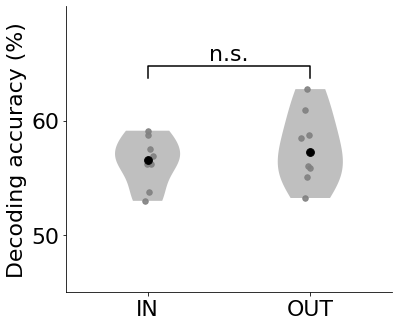

In [19]:
target_letters = ['F','B','C','G','V','D','N','R']
L    = len(target_letters)
idxs = [np.where(t == uniqueLetters)[0][0] for t in target_letters]

T1 = 2
T2 = 16
T  = T2 - T1

acc_IN = []
for k in range(20):
    al_real = []
    all_Letters = np.load(f'../single_letter_IN_{k}.npy')
    for letter_index in range(15):       
        al_real.append(np.diag(all_Letters[letter_index]))
    al_real = np.array(al_real)  # shape: (n_subjects, n_times)
    acc_IN.append(al_real)
acc_IN = np.array(acc_IN)
acc_IN = np.array([
    np.cumsum(acc_IN[:, i, T1:T2], axis=-1)[:, -1] / T
    for i in idxs
])
print(acc_IN.shape)

acc_OUT = []
for k in range(20):
    al_real = []
    all_Letters = np.load(f'../single_letter_OUT_{k}.npy')
    for letter_index in range(15):       
        al_real.append(np.diag(all_Letters[letter_index]))
    al_real = np.array(al_real)  # shape: (n_subjects, n_times)
    acc_OUT.append(al_real)
acc_OUT = np.array(acc_OUT)

# True accuracies per letter across runs at the last cumulative step
acc_OUT = np.array([
    np.cumsum(acc_OUT[:, i, T1:T2], axis=-1)[:, -1] / T
    for i in idxs
])
print(acc_OUT.shape)

import matplotlib
matplotlib.rcParams.update({'font.size': 22})


dIN  = np.median(acc_IN, axis=1)
dOUT = np.median(acc_OUT, axis=1)

# Only compare 4 and 6
data      = [dIN, dOUT]
positions = [4, 6]
colors    = ['gray', 'gray']

fig, ax = plt.subplots(figsize=(6, 5))

# For reproducible jitter
rng = np.random.default_rng(0)

for d, pos, color in zip(data, positions, colors):
    # Violin for this set size
    vp = ax.violinplot(d,
                       positions=[pos],
                       widths=0.8,
                       showmeans=False,
                       showmedians=False,
                       showextrema=False)

    # Color the violin
    for body in vp['bodies']:
        body.set_facecolor(color)
        body.set_alpha(0.5)

    # Scatter points on top of the violin
    x_jitter = rng.normal(loc=pos, scale=0.05, size=len(d))
    ax.scatter(x_jitter, d, color=color, s=30, zorder=3, alpha=0.9)

# --- Add median dots in black ---
medians = [np.median(d) for d in data]
ax.scatter(positions, medians, color='black', s=60, zorder=4)

# =========================================================
#      Paired permutation test on MEDIAN difference
#      H1: median(d4 - d6) > 0
# =========================================================

def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

def permutation_test_paired_median_greater(x, y, n_perm=200000, rng=None):
    """
    One-sided paired permutation test for H1: median(x - y) > 0.

    Test statistic = median(x - y).
    Null is generated by random sign-flips of the paired differences.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    if x.shape != y.shape:
        raise ValueError("x and y must have the same shape for a paired test")

    diff = x - y
    obs_stat = np.median(diff)

    if rng is None:
        rng = np.random.default_rng(1)

    n = diff.size
    # Random sign flips for each permutation
    signs = rng.choice([-1, 1], size=(n_perm, n))
    perm_diffs = np.median(signs * diff, axis=1)

    # One-sided p-value: P(perm_stat >= obs_stat)
    p_value = (np.sum(perm_diffs >= obs_stat) + 1) / (n_perm + 1)

    return obs_stat, p_value

# Non-parametric paired permutation test: 4 vs 6 (H1: d4 > d6)
stat_468, p_468 = permutation_test_paired_median_greater(dIN, dOUT)
print(f"Permutation test 4 vs 6 (median): stat = {stat_468:.3f}, p = {p_468:.4g}")

# --- Bracket and stars for 4–68 ---
ymax_data = max([np.max(d) for d in data])
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax_data + 0.05)  # room for bracket

base_y = ymax_data + 0.01      # height for the comparison line
line_h = 0.01                  # small vertical rise for bracket

stars = p_to_stars(p_468)
ax.plot([4, 4, 6, 6],
        [base_y, base_y + line_h, base_y + line_h, base_y],
        lw=1.5, c='black')
ax.text((4 + 6)/2, base_y + line_h + 0.002,
        stars, ha='center', va='bottom')

# Axis formatting
#ax.set_xlabel('Set Size')
ax.set_ylabel('Decoding accuracy (%)')
ax.set_xticks(positions)
ax.set_xticklabels(['IN', 'OUT'])

ax.set_yticks([0.5, 0.6], [50, 60])
ax.set_ylim(0.45, 0.7)
ax.set_xlim(3, 7)   # padding around the violins
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('acc_dec_INvsOUT_permMedian.svg', dpi=200)
plt.show()